In [1]:
from matplotlib import pylab 
params = {'xtick.labelsize': 18, 
'ytick.labelsize': 18, 
'axes.titlesize' : 22, 
'axes.labelsize' : 20, 
'legend.fontsize': 10, 
'legend.title_fontsize': 14, 
'figure.titlesize': 24 } 
pylab.rcParams.update(params)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dataset = pd.read_csv('virus_data.csv')

C:\Users\t-amuslih\AppData\Local\Temp\ipykernel_19772\302325336.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
from sklearn.model_selection import train_test_split 
from prepare import prepare_data
train_set,test_set= train_test_split(dataset,test_size=0.2, random_state=108)
normalized_train_set = prepare_data(train_set,train_set)
normalized_test_set = prepare_data(train_set,test_set)


c:\Users\t-amuslih\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


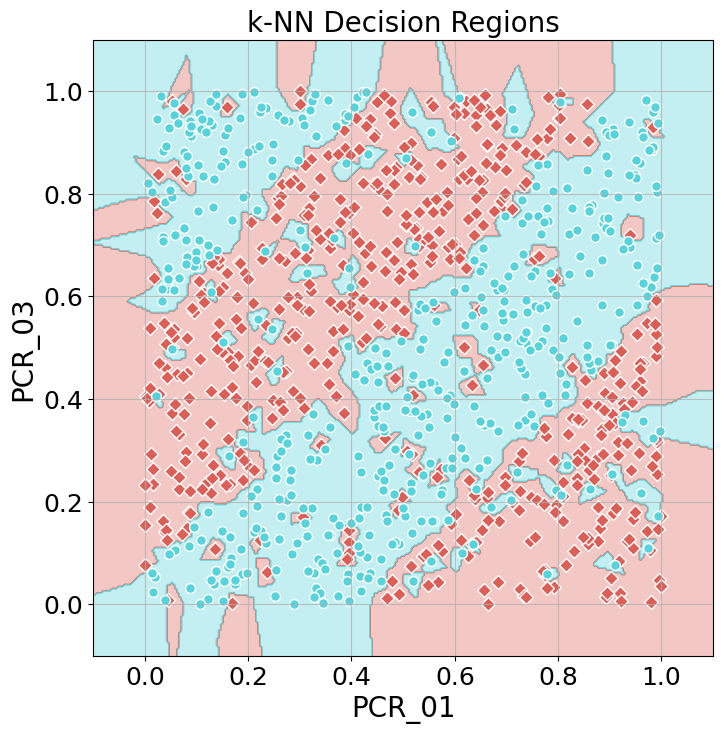

In [4]:
#Part 1 - Q1
from sklearn.neighbors import KNeighborsClassifier
from visualize_clf import visualize_clf

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(normalized_train_set[['PCR_01', 'PCR_03']], train_set['spread'])

visualize_clf(knn, normalized_train_set[['PCR_01', 'PCR_03']], train_set['spread'], title='k-NN Decision Regions', xlabel='PCR_01', ylabel='PCR_03')


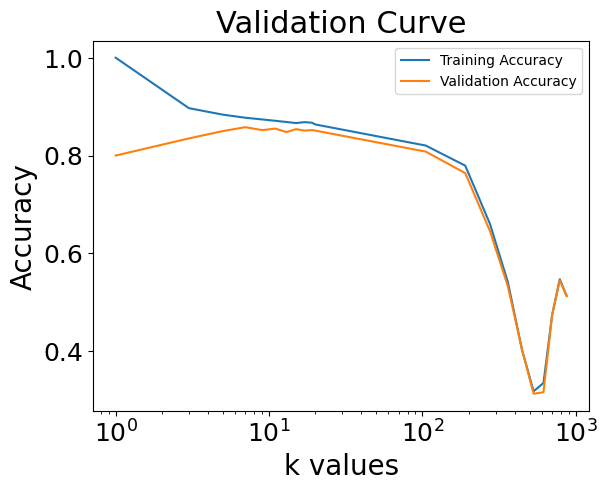

Best k value: 7
Best validation accuracy: 0.858
training accuracy: 0.8772857142857142


In [5]:
#Part 1 - Q2
from sklearn.model_selection import cross_validate
# Define the range of k values
k_values = list(range(1, 20, 2)) + list(range(20, 871, 85))

# Initialize empty lists to store the validation_scores and train scores
train_scores = []
validation_scores = []

# Perform cross-validation for each k value
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(knn, normalized_train_set[['PCR_01', 'PCR_03']], train_set['spread'], cv=8, return_train_score=True)
    train_scores.append(scores['train_score'].mean())
    validation_scores.append(scores['test_score'].mean())

# Plot the results
plt.semilogx(k_values, train_scores, label='Training Accuracy')
plt.semilogx(k_values, validation_scores, label='Validation Accuracy')
plt.xlabel('k values')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.show()

print('Best k value:', k_values[np.argmax(validation_scores)])
print('Best validation accuracy:', max(validation_scores))
print('training accuracy:', train_scores[np.argmax(validation_scores)])



7


c:\Users\t-amuslih\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


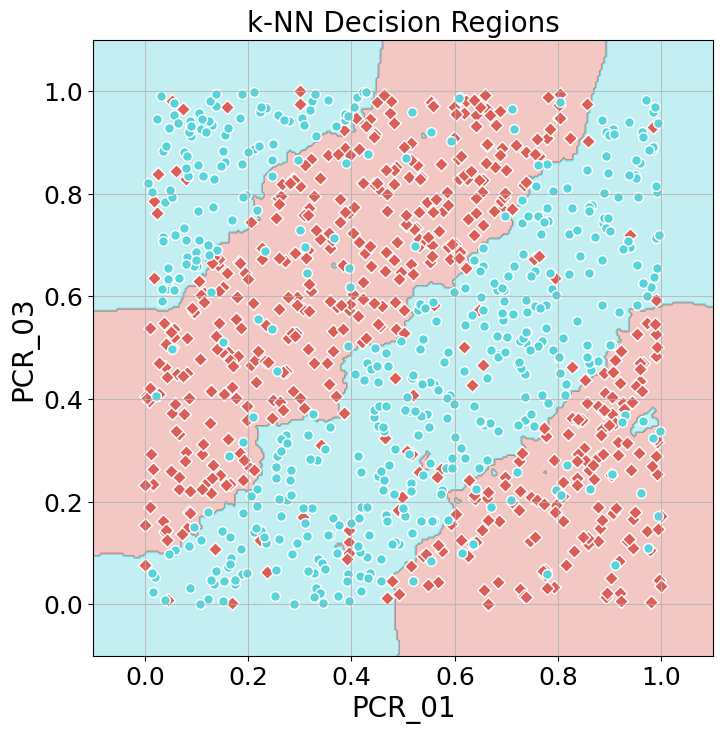

Test Accuracy: 0.848


In [6]:
#Part 1 - Q3 - fix
# Retrain k-NN model on all training samples with the optimal k value
best_k = k_values[np.argmax(validation_scores)]
print(best_k)
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(normalized_train_set[['PCR_01', 'PCR_03']], train_set['spread'])

# Plot the decision regions of the final model
visualize_clf(knn, normalized_train_set[['PCR_01', 'PCR_03']], train_set['spread'], title='k-NN Decision Regions', xlabel='PCR_01', ylabel='PCR_03')

# Compute the test accuracy of the final model
test_accuracy = knn.score(prepare_data(train_set, test_set)[['PCR_01', 'PCR_03']], test_set['spread'])
print('Test Accuracy:', test_accuracy)


Training Accuracy: 0.715


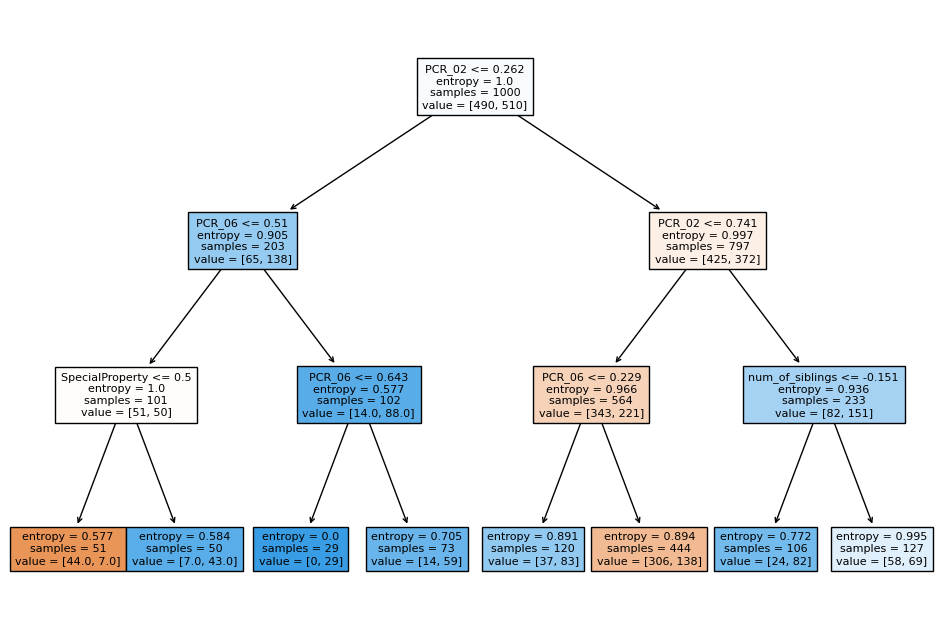

In [7]:
#Part 2 - Q5
from sklearn.tree import DecisionTreeClassifier, plot_tree

train_set_X = normalized_train_set.drop(['spread', 'risk'], axis=1)
train_set_Y = train_set['risk']

# Create the decision tree classifier
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3)

# Fit the model to the training data
dt.fit(train_set_X, train_set_Y)

# Calculate the training accuracy
train_accuracy = dt.score(train_set_X, train_set_Y)
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=train_set_X.columns, filled=True, fontsize=8)
print('Training Accuracy:', train_accuracy)



Best Parameters: {'max_depth': 17, 'min_samples_leaf': 13}
Best Validation Score: 0.762


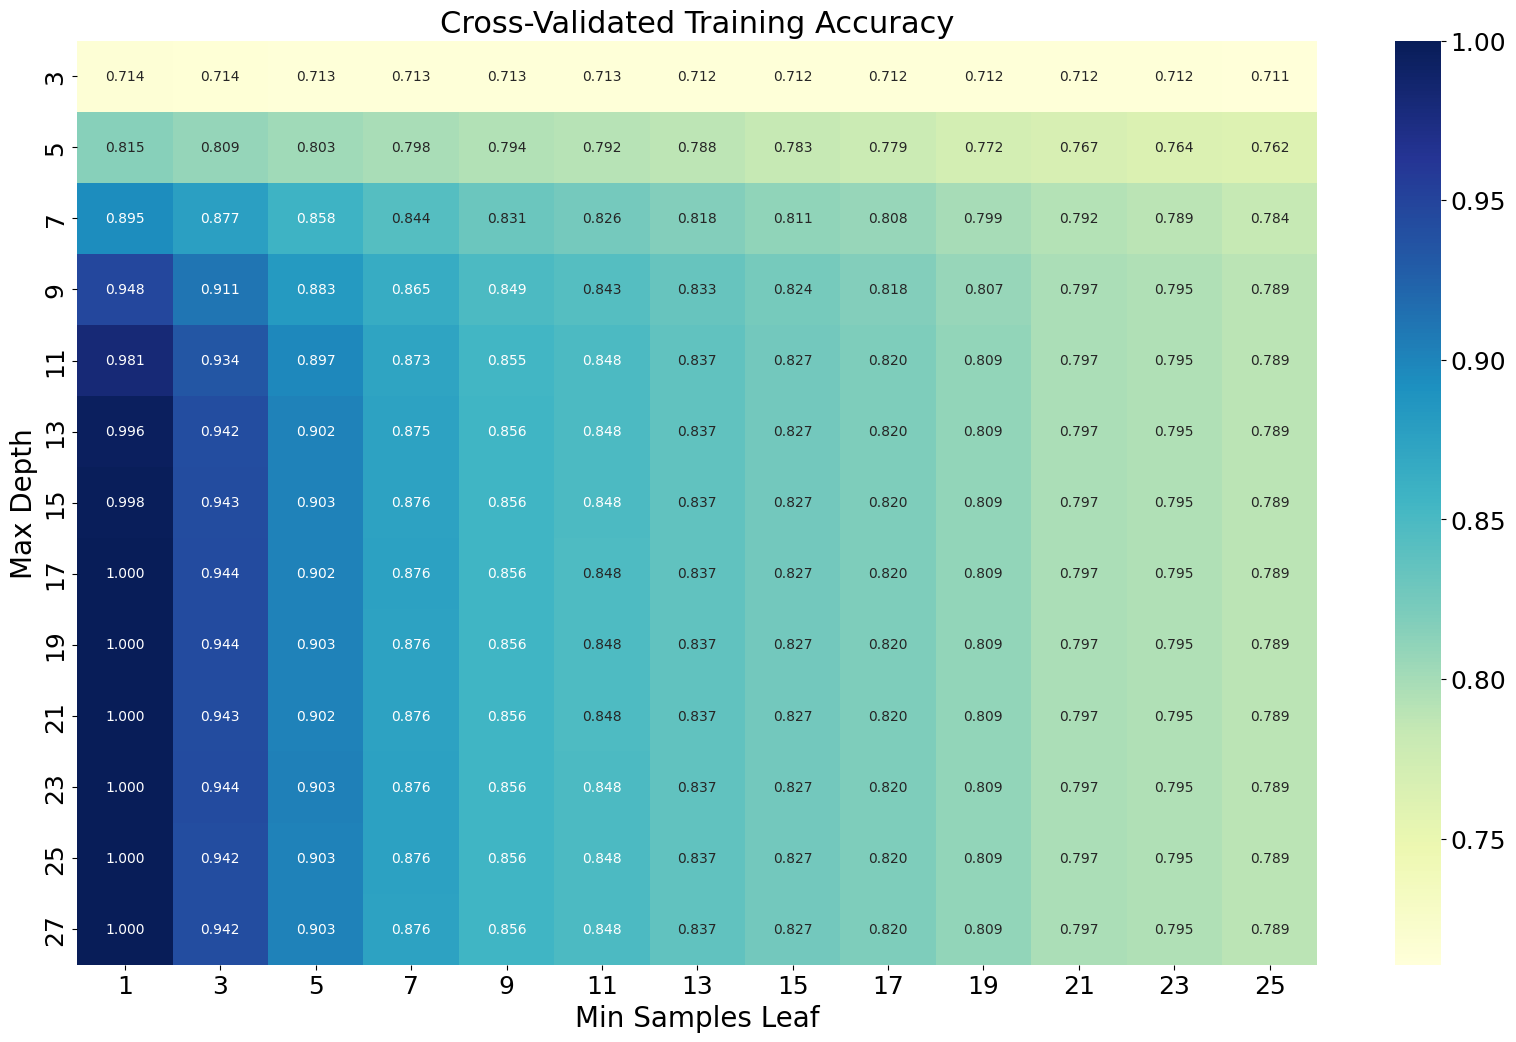

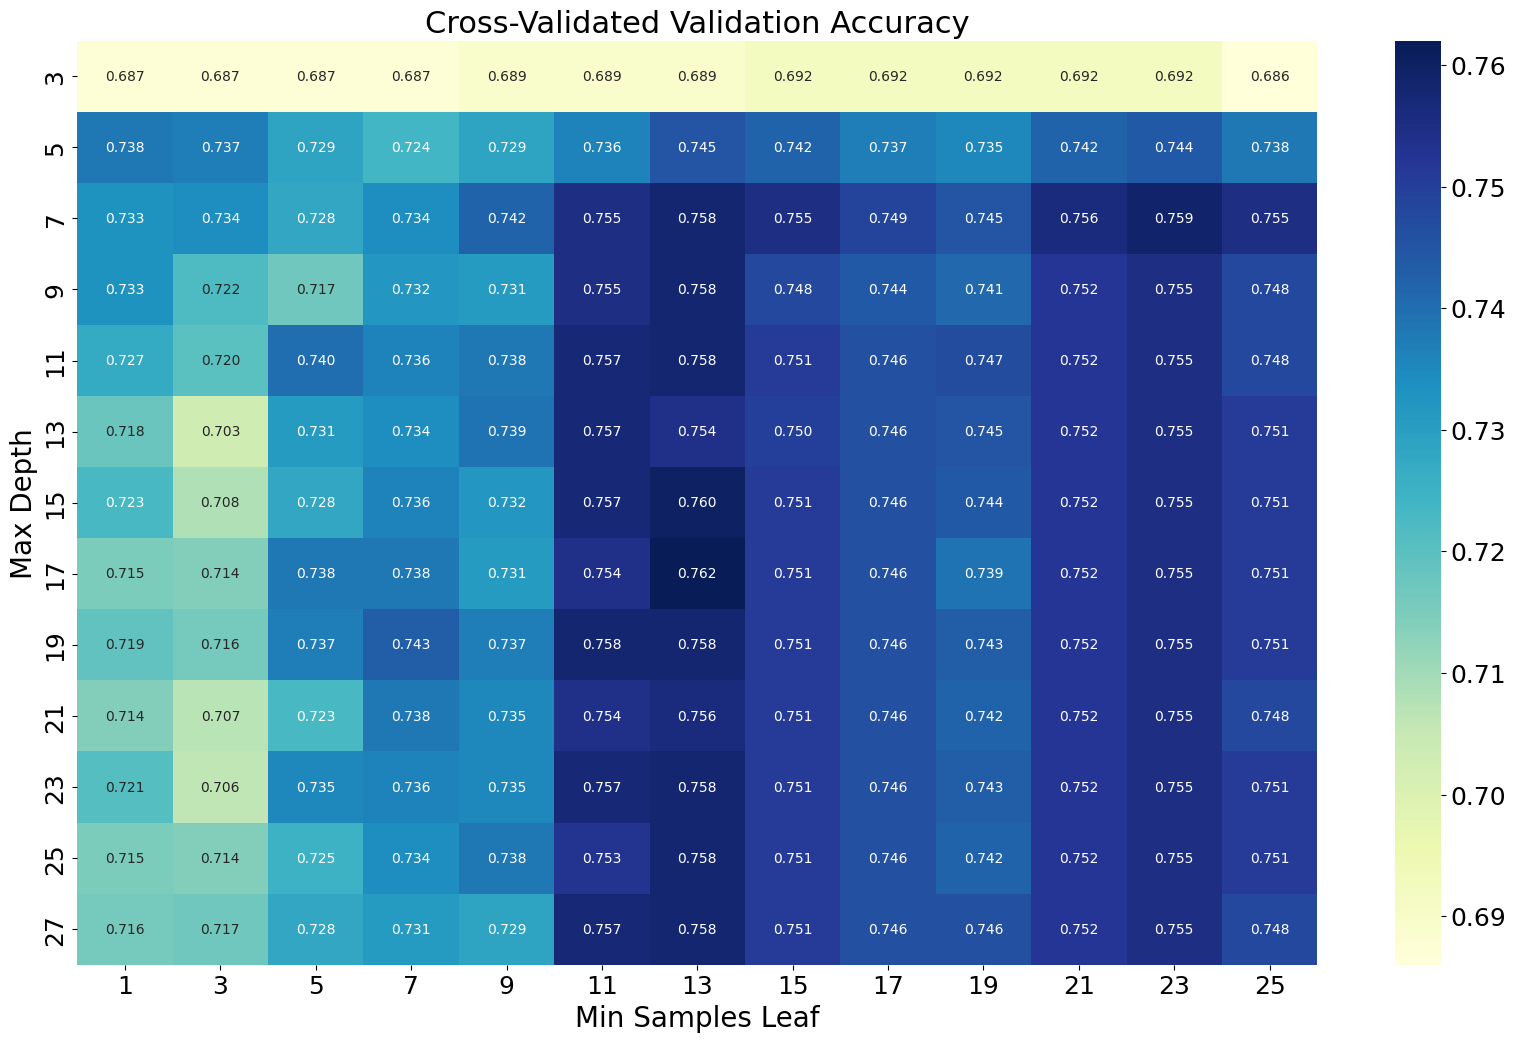

In [8]:
#Part 2 - Q6 - fix
from sklearn.model_selection import GridSearchCV

train_set_X = normalized_train_set.drop(['spread', 'risk'], axis=1)
train_set_Y = train_set['risk']
# Define the parameter grid
param_grid = {
    'min_samples_leaf': range(1, 26, 2),
    'max_depth': range(3, 28, 2)
}

# Create the decision tree classifier
dt = DecisionTreeClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(dt, param_grid, cv=5, return_train_score=True)

# Fit the grid search to the training data
grid_search.fit(train_set_X, train_set_Y)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Best Parameters:', best_params)
print('Best Validation Score:', best_score)

# Get the training and validation scores from the grid search
train_scores = grid_search.cv_results_['mean_train_score'].reshape(len(param_grid['min_samples_leaf']), len(param_grid['max_depth']))
validation_scores = grid_search.cv_results_['mean_test_score'].reshape(len(param_grid['min_samples_leaf']), len(param_grid['max_depth']))

# Plot the heatmap for training accuracy
plt.figure(figsize=(20, 12))
sns.heatmap(train_scores,annot=True, fmt=".3f", cmap='YlGnBu', xticklabels=param_grid['min_samples_leaf'], yticklabels=param_grid['max_depth'])
plt.xlabel('Min Samples Leaf')
plt.ylabel('Max Depth')
plt.title('Cross-Validated Training Accuracy')
plt.show()

# Plot the heatmap for validation accuracy
plt.figure(figsize=(20, 12))
sns.heatmap(validation_scores, annot=True, fmt=".3f", cmap='YlGnBu', xticklabels=param_grid['min_samples_leaf'], yticklabels=param_grid['max_depth'])
plt.xlabel('Min Samples Leaf')
plt.ylabel('Max Depth')
plt.title('Cross-Validated Validation Accuracy')
plt.show()


In [9]:
#Part 2 - Q8
from sklearn.tree import DecisionTreeClassifier

# Set the optimal hyperparameters
max_depth = best_params['max_depth']
min_samples_leaf = best_params['min_samples_leaf']

# Create the decision tree classifier with the optimal hyperparameters
dt = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, min_samples_leaf=min_samples_leaf)

X_train = normalized_train_set.drop(['spread', 'risk'], axis=1)
Y_train = train_set['risk']
X_test = prepare_data(train_set, test_set).drop(['spread', 'risk'], axis=1)
Y_test = test_set['risk']
# Fit the model to the entire training data
dt.fit(X_train, Y_train)

# Calculate the test accuracy of the final model
test_accuracy = dt.score(X_test, Y_test)
print('Test Accuracy:', test_accuracy)


Test Accuracy: 0.7


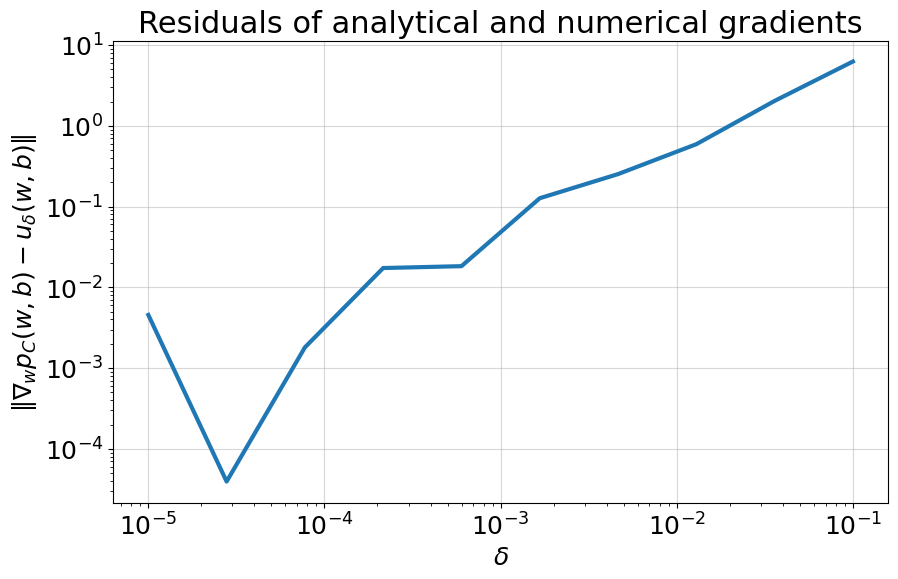

In [10]:
#Part 3 - Q9
from verify_gradients import compare_gradients
X_train = normalized_train_set[['PCR_01', 'PCR_03']].values
Y_train = train_set['spread'].values
compare_gradients(X_train, Y_train, deltas=np.logspace(-5,-1,10))


[1.e-09 1.e-08 1.e-07 1.e-06 1.e-05]


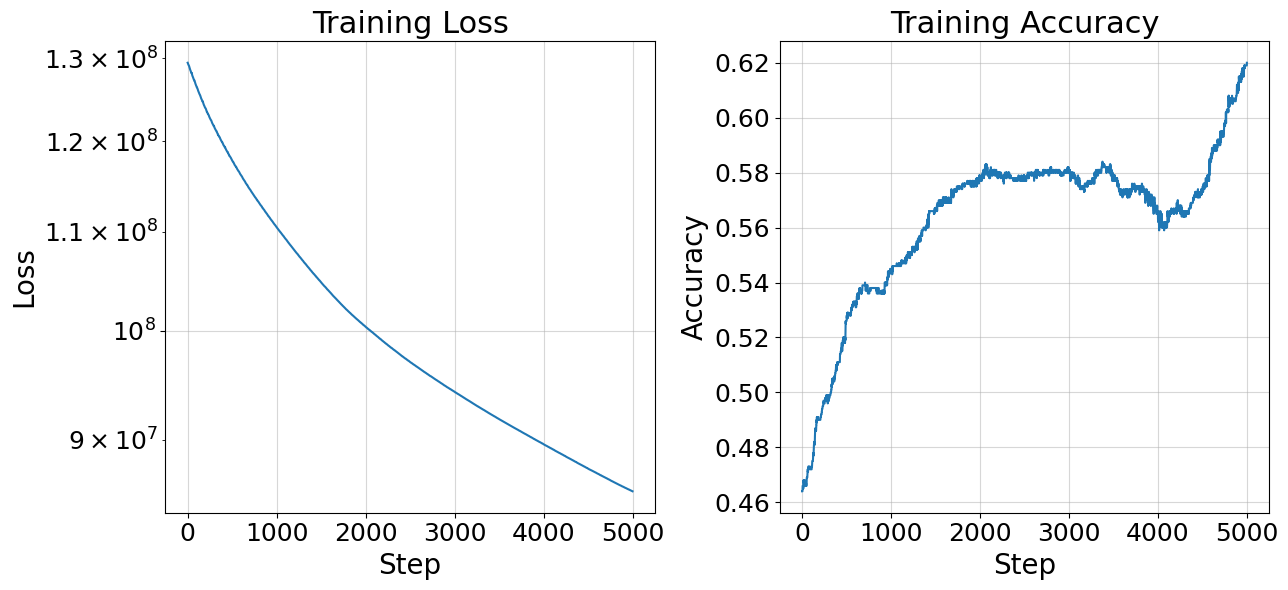

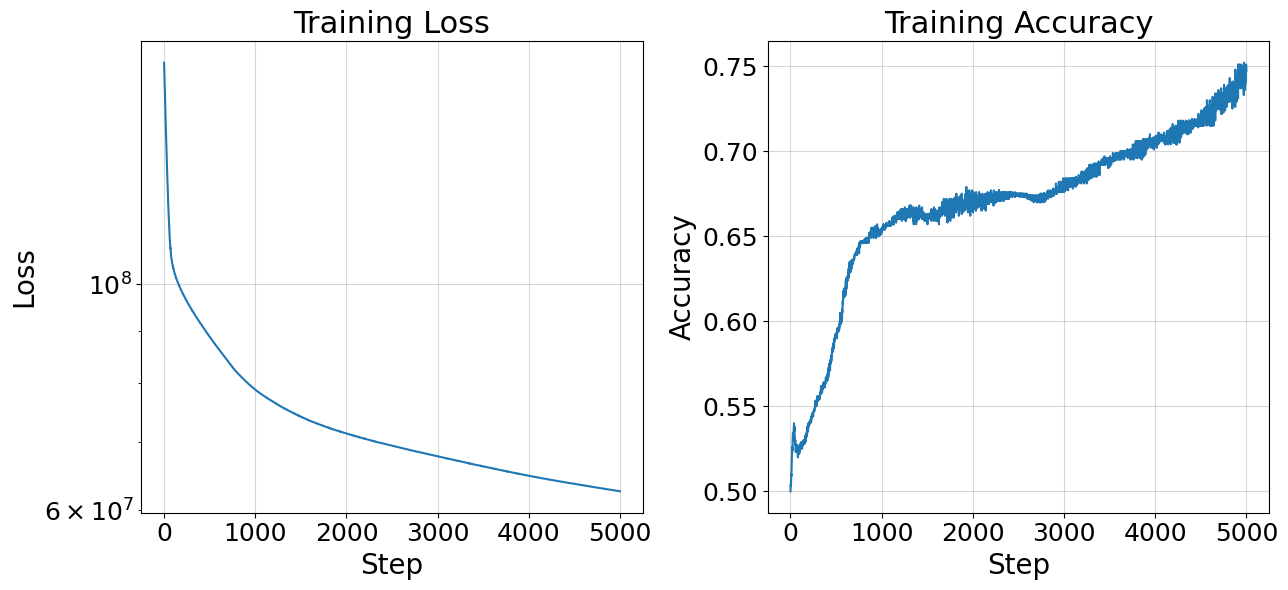

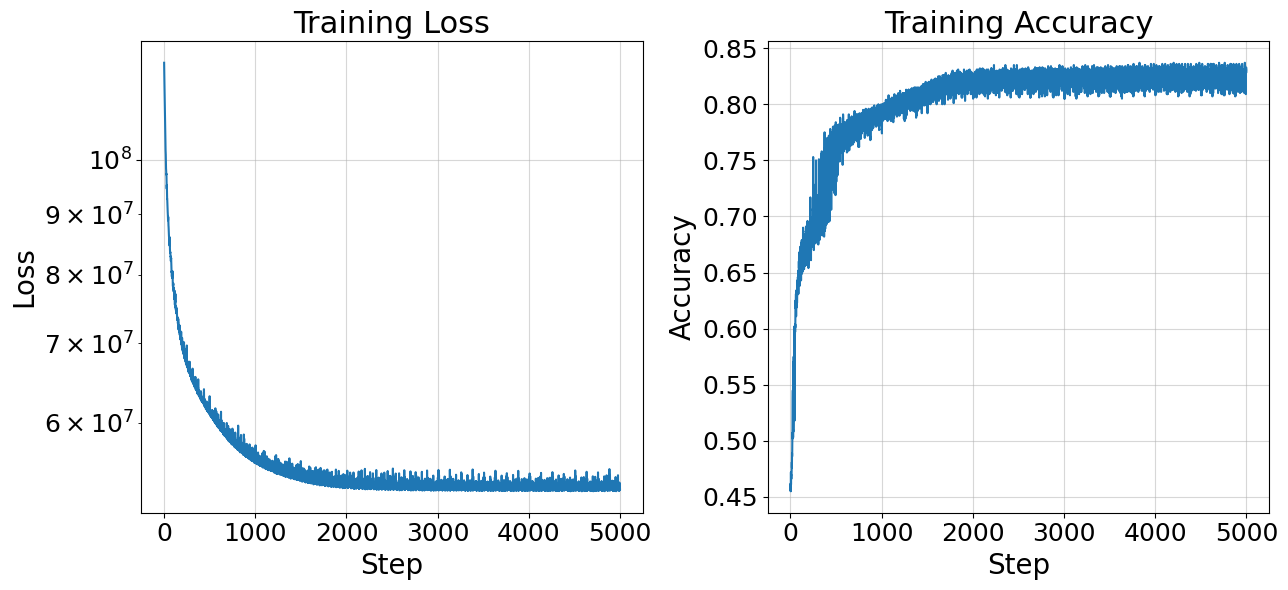

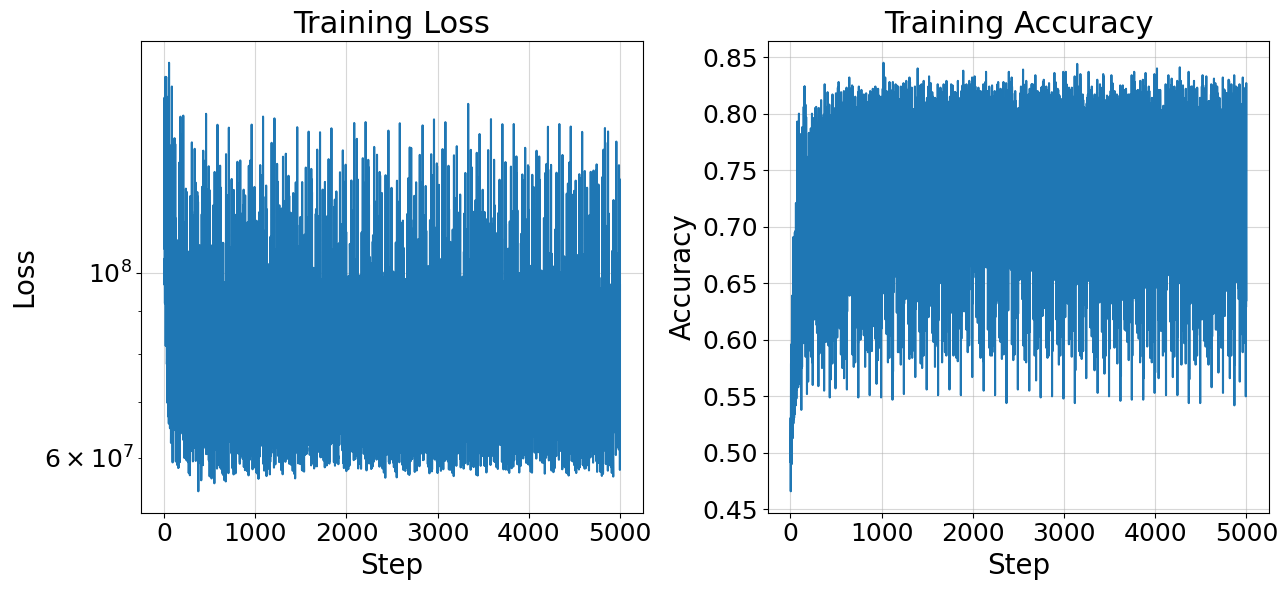

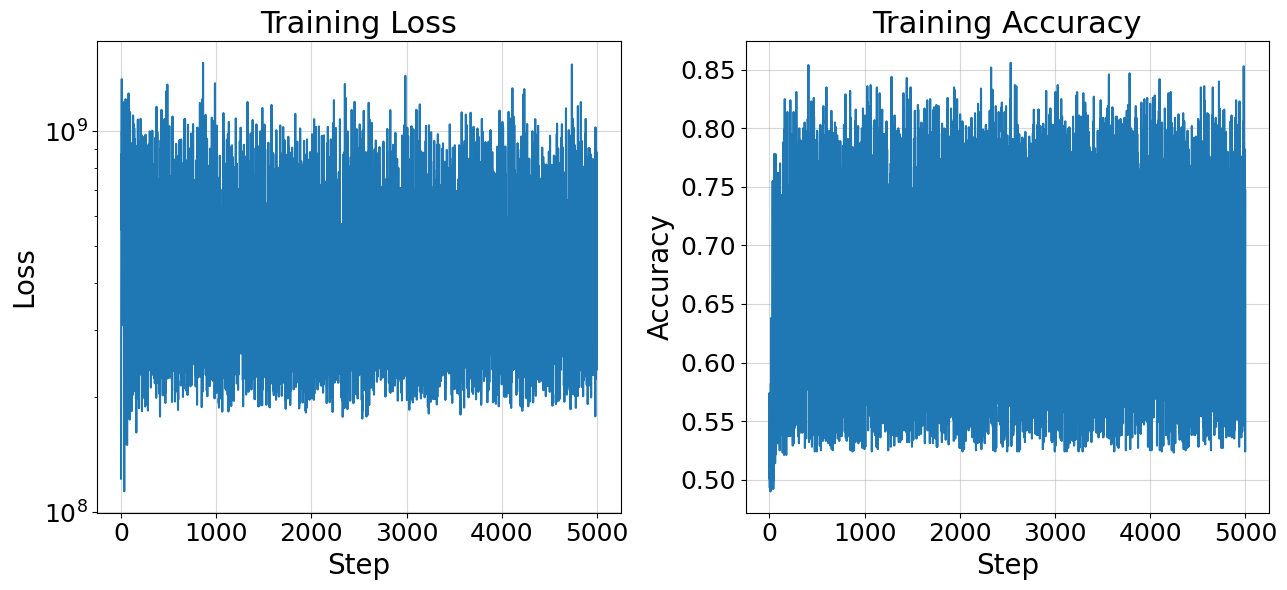

In [11]:
#Part 3 - Q11
from SoftSVM import SoftSVM
from sklearn.preprocessing import MinMaxScaler,PolynomialFeatures

lr_range = np.logspace(-9, -5, 5)
print(lr_range)
C = 1e5
X_train = train_set[['PCR_01', 'PCR_03']].values
Y_train = train_set['spread'].values

Xtrain_poly = PolynomialFeatures(degree=3).fit_transform(X_train)
Xtrain_poly = MinMaxScaler(feature_range=(-1, 1)).fit_transform(Xtrain_poly)
for lr in lr_range:
  clf = SoftSVM(C=C, lr=lr)
  losses, accuracies = clf.fit_with_logs(Xtrain_poly, Y_train, max_iter=5000)
  
  plt.figure(figsize=(13, 6))
  plt.subplot(121), plt.grid(alpha=0.5), plt.title("Training Loss")
  plt.semilogy(losses), plt.xlabel("Step"), plt.ylabel("Loss")
  plt.subplot(122), plt.grid(alpha=0.5), plt.title("Training Accuracy")
  plt.plot(accuracies), plt.xlabel("Step"), plt.ylabel("Accuracy")
  plt.tight_layout()
  plt.show()


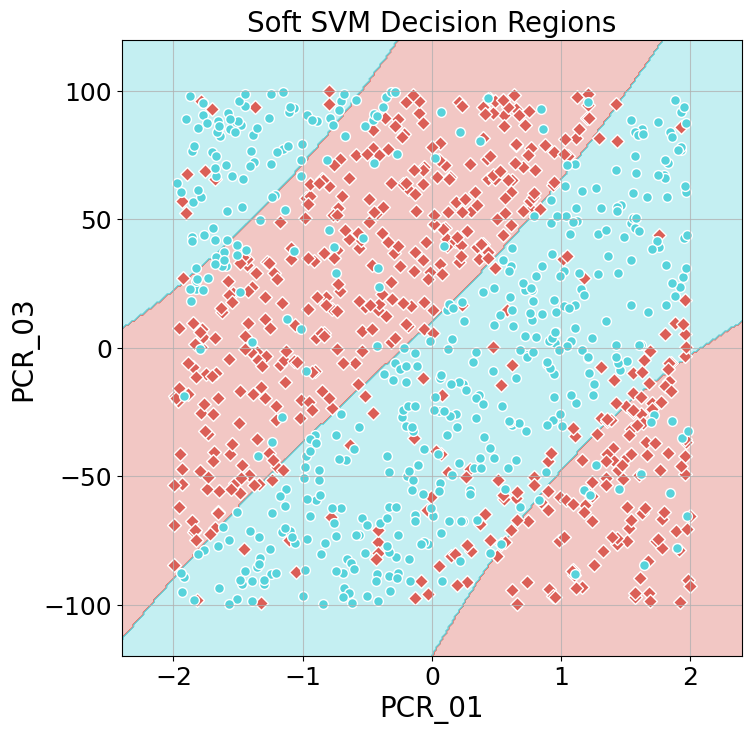

Training Accuracy: 0.819
Test Accuracy: 0.836


In [12]:
# Part 3 - Q12
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler 
from visualize_clf import visualize_clf
from SoftSVM import SoftSVM

X_train = train_set[['PCR_01', 'PCR_03']].values
Y_train = train_set['spread'].values

svm_clf = Pipeline([('feature_mapping', PolynomialFeatures(degree=3)), ('scaler', MinMaxScaler()), ('SVM', SoftSVM(C=1e5, lr=1e-7))])
svm_clf.fit(X_train, Y_train, SVM__max_iter=5000)
visualize_clf(svm_clf, X_train, Y_train, title='Soft SVM Decision Regions', xlabel='PCR_01', ylabel='PCR_03')

# Calculate the training accuracy
train_accuracy = svm_clf.score(X_train, Y_train)

# Calculate the test accuracy
test_accuracy = svm_clf.score(test_set[['PCR_01', 'PCR_03']].values, test_set['spread'].values)

print('Training Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)

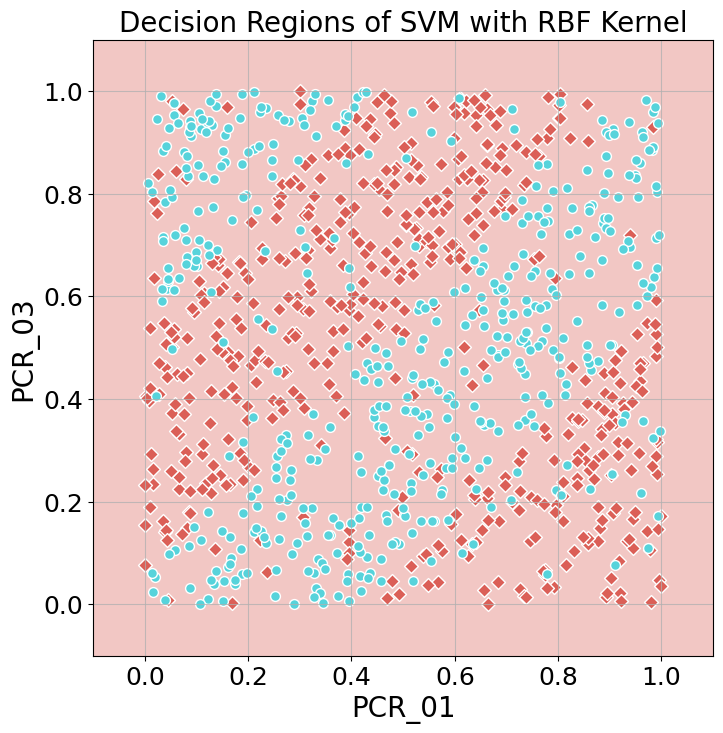

In [13]:
# Part 3 - Q14
from sklearn.svm import SVC
# Create the SVM model
svm_model1 = SVC(kernel='rbf', C=1, gamma=1e-7)

X_train = normalized_train_set[['PCR_01', 'PCR_03']].values
Y_train = train_set['spread'].values

# Fit the model to the data
svm_model1.fit(X_train, Y_train)

visualize_clf(svm_model1, X_train, Y_train, title='Decision Regions of SVM with RBF Kernel', xlabel='PCR_01', ylabel='PCR_03')# Part 3 - Q14

c:\Users\t-amuslih\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


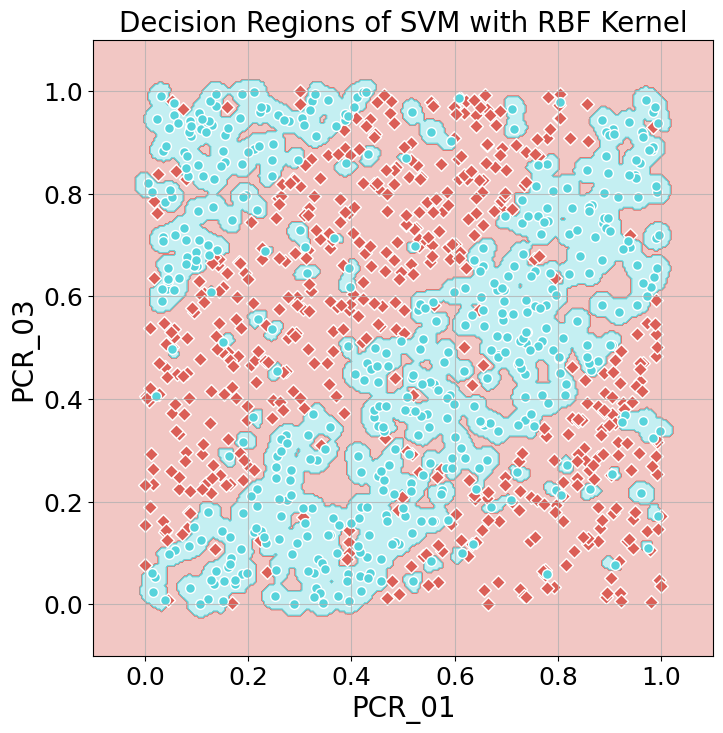

In [14]:
# Part 3 - Q15 - fix
from sklearn.svm import SVC
# Create the SVM model
svm_model2 = SVC(kernel='rbf', C=1, gamma=5000)

X_train = normalized_train_set[['PCR_01', 'PCR_03']]
Y_train = train_set['spread']

# Fit the model to the data
svm_model2.fit(X_train, Y_train)

visualize_clf(svm_model2, X_train, Y_train, title='Decision Regions of SVM with RBF Kernel', xlabel='PCR_01', ylabel='PCR_03')

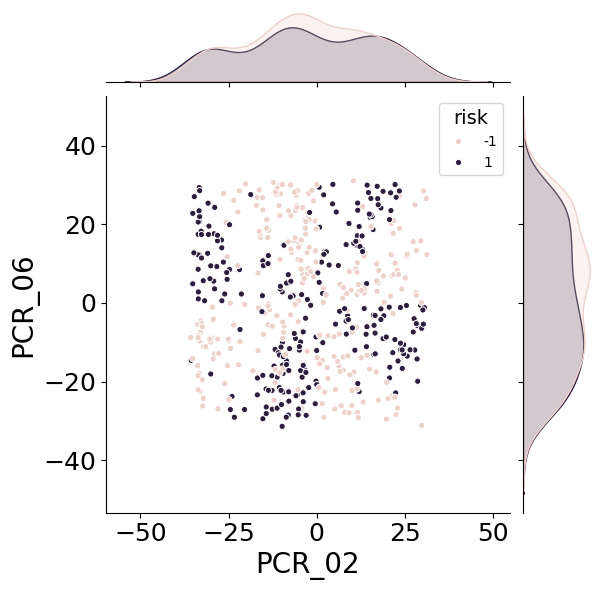

In [15]:
# Part 3 - Q16
# Create temporary train dataframe
train_part5 = train_set[(normalized_train_set['SpecialProperty'] == 0)][['PCR_02', 'PCR_06', 'risk']]

# Create temporary test dataframe
test_part5 = test_set[(normalized_test_set['SpecialProperty'] == 0)][['PCR_02', 'PCR_06', 'risk']]

# Attach sns.jointplot
sns.jointplot(data=train_part5, x='PCR_02', y='PCR_06', hue='risk', marker='.', s=80)

(-0.01, 0.11839494206331636)

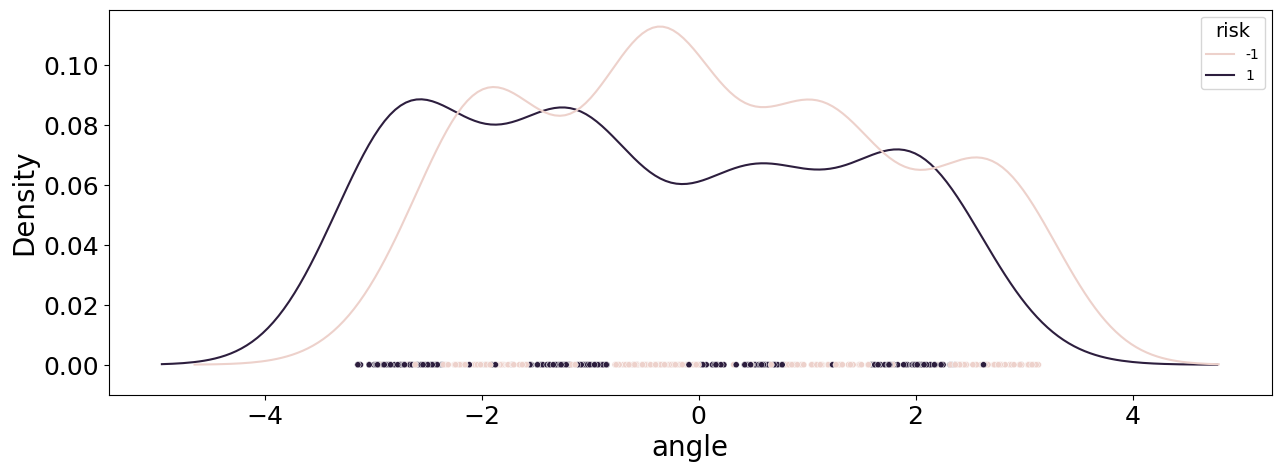

In [16]:
# Part 3 - Q17
# Calculate the angle in radians
train_part5['angle'] = np.arctan2(train_part5['PCR_02'],train_part5['PCR_06'])
plt.figure(figsize=(15, 5)) 
sns.scatterplot(data=train_part5, x='angle', y=[0]*train_part5.shape[0], hue='risk', s=20) 
sns.kdeplot(data= train_part5, x='angle', hue='risk', common_norm=True, fill=False) 
plt.ylim(bottom=-1e-2)


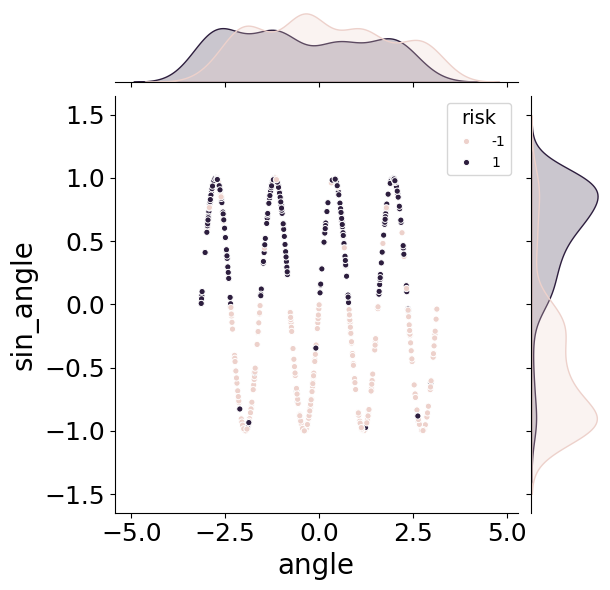

In [17]:
# Part 3 - Q17
beta=4
train_part5['sin_angle'] = np.sin(beta*train_part5['angle'])
sns.jointplot(data=train_part5, x='angle', y='sin_angle', hue='risk', marker='.', s=80)

c:\Users\t-amuslih\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Training Accuracy: 0.9069767441860465
Test Accuracy: 0.9117647058823529


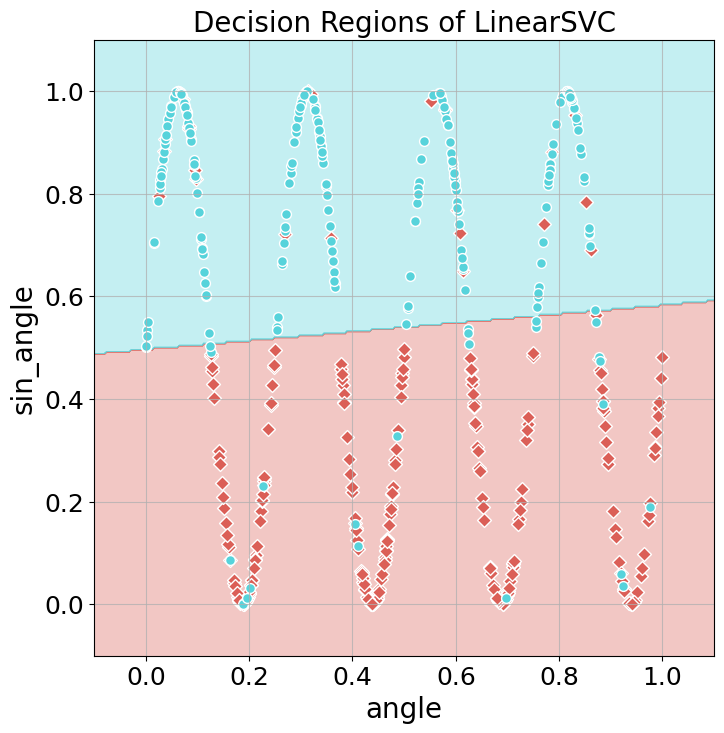

In [18]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

beta=4
train_part5['sin_angle'] = np.sin(beta*train_part5['angle'])
test_part5['angle'] = np.arctan2(test_part5['PCR_02'],test_part5['PCR_06'])
test_part5['sin_angle'] = np.sin(beta*test_part5['angle'])
# Normalize the mapped features
scaler = MinMaxScaler()
train_part5_normalized = scaler.fit_transform(train_part5[['angle','sin_angle']])
test_part5_normalized = scaler.transform(test_part5[['angle','sin_angle']])
# Train the LinearSVC model
svc_model = LinearSVC()
svc_model.fit(train_part5_normalized, train_part5['risk'])

# Calculate the accuracies
train_accuracy = svc_model.score(train_part5_normalized, train_part5['risk'])
test_accuracy = svc_model.score(test_part5_normalized, test_part5['risk'])

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Plot the decision regions
visualize_clf(svc_model, train_part5_normalized, train_part5['risk'], title='Decision Regions of LinearSVC', xlabel='angle', ylabel='sin_angle')
